In [1]:
import torch
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from scipy.stats import norm
from einops import rearrange
from lightning.pytorch.utilities import move_data_to_device

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))

from maps_to_cosmology.encoder import Encoder
from maps_to_cosmology.datamodule import ConvergenceMapsModule

plt.rcParams["font.family"] = "serif"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

param_names = [
    r"$\Omega_c$", r"$\Omega_b$", r"$\sigma_8$",
    r"$h_0$", r"$n_s$", r"$w_0$"
]

# WMAP-7 cosmology (DC2 truth)
wmap7_params = [0.22, 0.048, 0.80, 0.71, 0.963, -1.0]

## 1. Load trained encoder

In [2]:
ckpt = "../results/dc2_lognormal_npe_lr1e-5_1000epochs/checkpoints/encoder_epoch=779.ckpt"
encoder = Encoder.load_from_checkpoint(ckpt, weights_only=False)
encoder.eval()
encoder.to(device)

Encoder(
  (train_rmse): RootMeanSquaredError()
  (train_pcc): PearsonCorrelationCoefficient()
  (val_rmse): RootMeanSquaredError()
  (val_scatter): ScatterPlot()
  (val_pcc): PearsonCorrelationCoefficient()
  (test_rmse): RootMeanSquaredError()
  (test_scatter): ScatterPlot()
  (test_pcc): PearsonCorrelationCoefficient()
  (net): ResNet(
    (stem): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
    )
    (layer1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (layer2): ResidualBlock(
      (conv1): Conv2d(32, 64, ke

## 2. Load DC2 true convergence map

Same assembly logic as `verify_dc2_maps.ipynb`: load tiles from the DC2 test set (5 sbi_lens redshift bins), sort by RA/DEC, and rearrange into a 64x40x5 map.

In [3]:
data_dir = "/data/scratch/dc2local/dc2_lensing_splits_sbilensredshift"

with initialize_config_dir(config_dir=str(Path.cwd().parents[1] / "images_to_maps" / "dc2"), version_base=None):
    dc2_cfg = compose(
        "config_train_npe",
        {
            "surveys.dc2.cached_data_path=" + data_dir,
        },
    )

data_source = instantiate(dc2_cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()

num_tiles_per_side = 8
num_dc2_bins = 5
convergence_true = torch.zeros(
    len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device
)
ra = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device)
dec = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device)

for i, b in enumerate(test_dl):
    batch = move_data_to_device(b, device)
    convergence_true[i] = batch["tile_catalog"]["convergence"].squeeze()
    ra[i] = batch["tile_catalog"]["ra"].squeeze()
    dec[i] = batch["tile_catalog"]["dec"].squeeze()

print(f"DC2 convergence shape (per entry): {convergence_true.shape}")

# Sort by RA/DEC to assemble into a spatially-correct map
ra_mean = ra.mean([1, 2, 3])
dec_mean = dec.mean([1, 2, 3])

dec_sort_idx = torch.argsort(dec_mean)
dec_bins = dec_sort_idx.view(8, 5)

sorted_indices = torch.zeros_like(dec_bins)
for i in range(8):
    ra_in_row = ra_mean[dec_bins[i]]
    ra_sort_idx = torch.argsort(-ra_in_row)
    sorted_indices[i] = dec_bins[i][ra_sort_idx]

idx = sorted_indices.flatten()

# Rearrange into full map: (8 dec_rows, 5 ra_cols, 8, 8, 5) -> (64, 40, 5)
dc2_map = rearrange(
    convergence_true[idx].view(8, 5, num_tiles_per_side, num_tiles_per_side, num_dc2_bins),
    "h w nh nw b -> (h nh) (w nw) b",
).cpu()

print(f"DC2 assembled map shape: {dc2_map.shape}  (height, width, bins) = (64, 40, 5)")

DC2 convergence shape (per entry): torch.Size([40, 8, 8, 5])
DC2 assembled map shape: torch.Size([64, 40, 5])  (height, width, bins) = (64, 40, 5)


## 3. Run encoder on DC2 map

In [4]:
# Encoder expects (batch, bins, height, width)
dc2_input = rearrange(dc2_map, "h w b -> 1 b h w").to(device).float()
print(f"Encoder input shape: {dc2_input.shape}")

with torch.no_grad():
    out = encoder(dc2_input)
    dist = encoder.var_dist.get_dist(out)
    posterior_mean = dist.loc.squeeze(0).cpu()
    posterior_std = torch.sqrt(
        torch.diagonal(dist.covariance_matrix, dim1=-2, dim2=-1)
    ).squeeze(0).cpu()

print("\nPosterior summary for DC2 map:")
print(f"{'Param':>12}  {'Mean':>10}  {'Std':>10}  {'WMAP-7':>10}")
for i, name in enumerate(param_names):
    print(f"{name:>12}  {posterior_mean[i].item():>10.4f}  {posterior_std[i].item():>10.4f}  {wmap7_params[i]:>10.4f}")

Encoder input shape: torch.Size([1, 5, 64, 40])

Posterior summary for DC2 map:
       Param        Mean         Std      WMAP-7
  $\Omega_c$      0.0119      0.0442      0.2200
  $\Omega_b$      0.0492      0.0111      0.0480
  $\sigma_8$      1.1313      0.1841      0.8000
       $h_0$      0.6843      0.0843      0.7100
       $n_s$      0.7723      0.1163      0.9630
       $w_0$     -0.4345      0.3930     -1.0000


## 4. Posterior contour plot

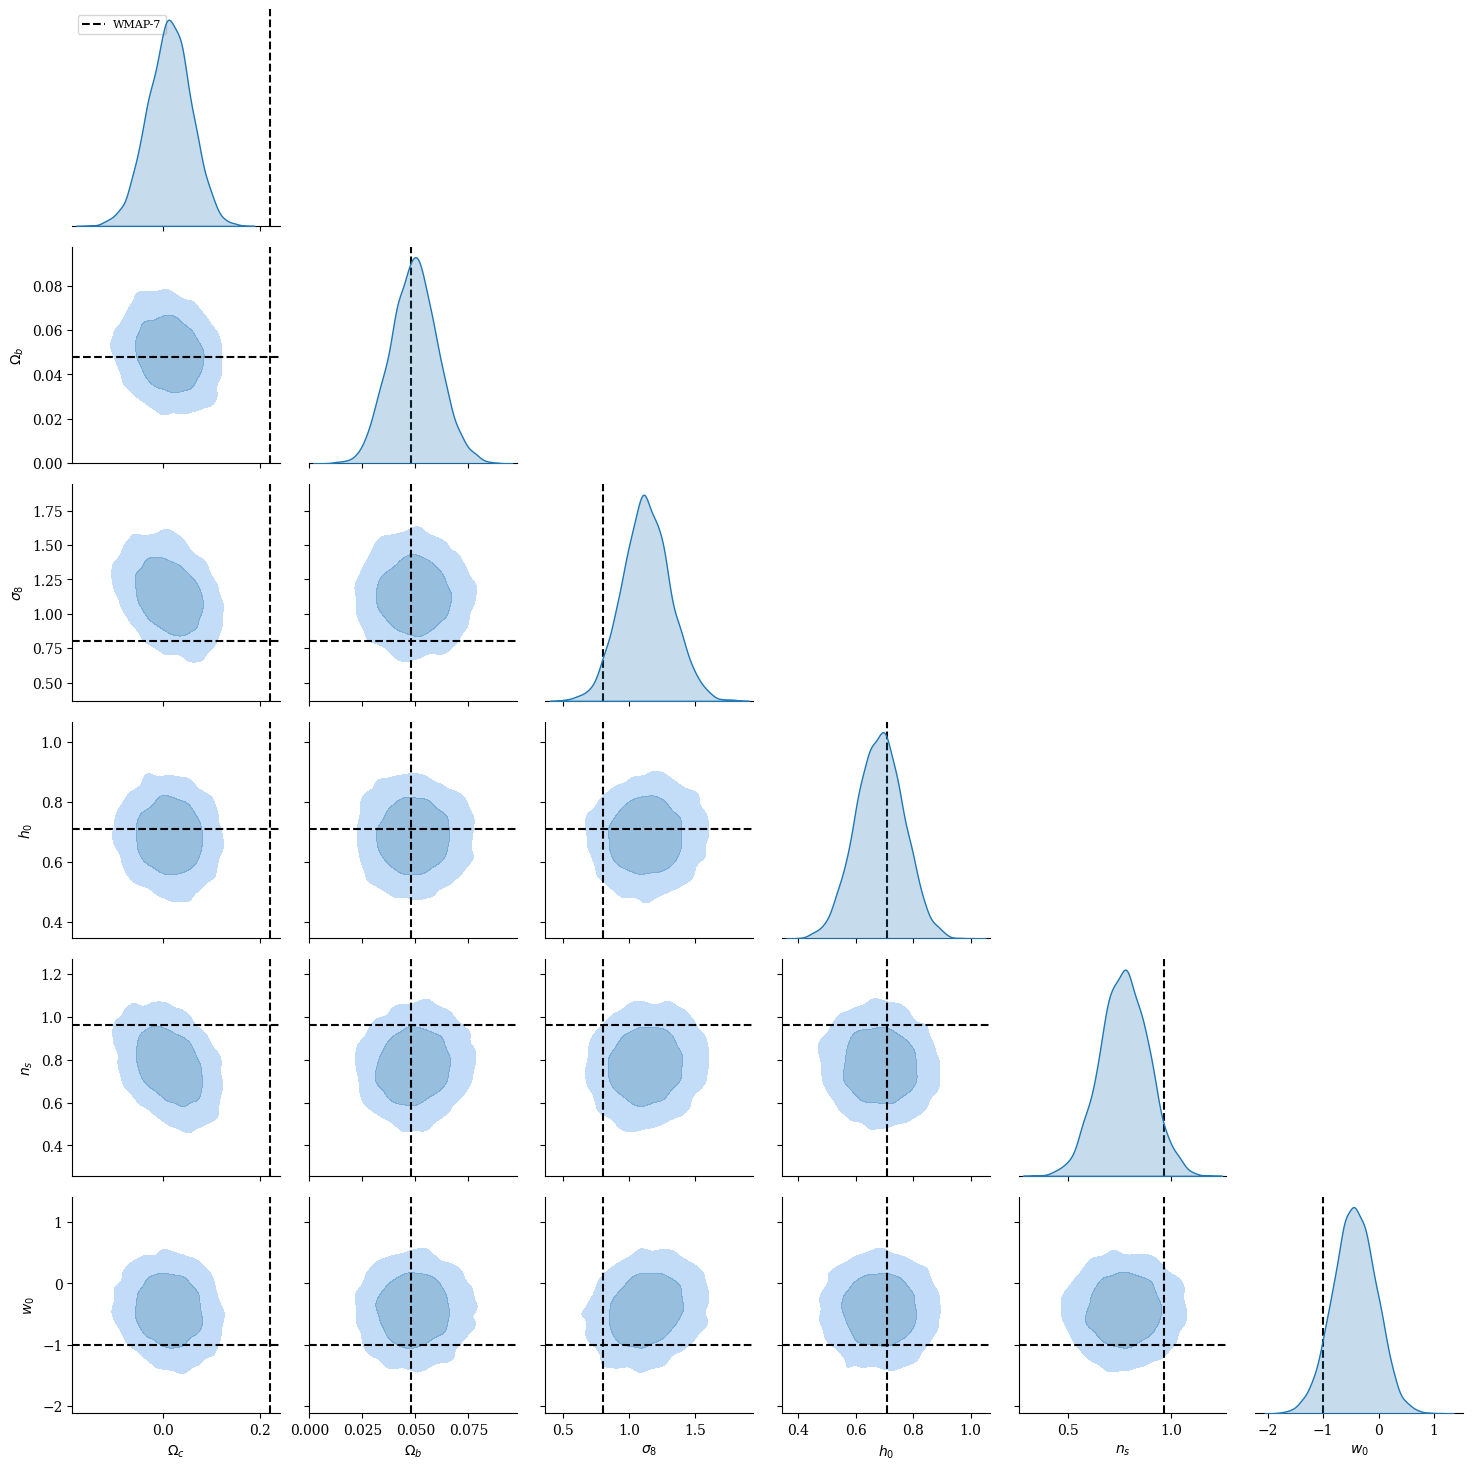

In [5]:
num_samples = 5000
samples = dist.rsample((num_samples,)).squeeze(1).cpu().numpy()
df = pd.DataFrame(samples, columns=param_names)

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

# Mark WMAP-7 truth
for i in range(6):
    g.axes[i, i].axvline(wmap7_params[i], color="black", linestyle="--", label="WMAP-7" if i == 0 else None)
    for j in range(i):
        g.axes[i, j].axvline(wmap7_params[j], color="black", linestyle="--")
        g.axes[i, j].axhline(wmap7_params[i], color="black", linestyle="--")

g.axes[0, 0].legend(fontsize=8)
plt.show()

## 5. Evaluate on sbi_lens test set

Scatter plots and calibration on the held-out sbi_lens test set (same geometry as training data).

In [6]:
datamodule = ConvergenceMapsModule(
    data_dir="/data/scratch/convergence_maps/dc2_lognormal",
    batch_size=32,
    num_workers=4,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    standardize_params=False,
)
datamodule.setup()
test_loader = datamodule.test_dataloader()

Loading data:   0%|          | 0/4983 [00:00<?, ?it/s]

Saving combined_batches.pt to /data/scratch/convergence_maps/dc2_lognormal
Loaded 79725 samples
Maps shape: torch.Size([79725, 64, 40, 5])
Params shape: torch.Size([79725, 6])
Train samples: 63781
Val samples: 7972
Test samples: 7972


In [7]:
posterior_means = []
posterior_stdevs = []
true_params = []

with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device)
        out = encoder(maps)
        d = encoder.var_dist.get_dist(out)
        posterior_mean_batch = d.loc
        posterior_std_batch = torch.sqrt(
            torch.diagonal(d.covariance_matrix, dim1=-2, dim2=-1)
        )
        posterior_means.append(posterior_mean_batch.cpu())
        posterior_stdevs.append(posterior_std_batch.cpu())
        true_params.append(params)

posterior_means = torch.cat(posterior_means, dim=0)
posterior_stdevs = torch.cat(posterior_stdevs, dim=0)
true_params = torch.cat(true_params, dim=0)

### Scatter plots: true vs posterior mean

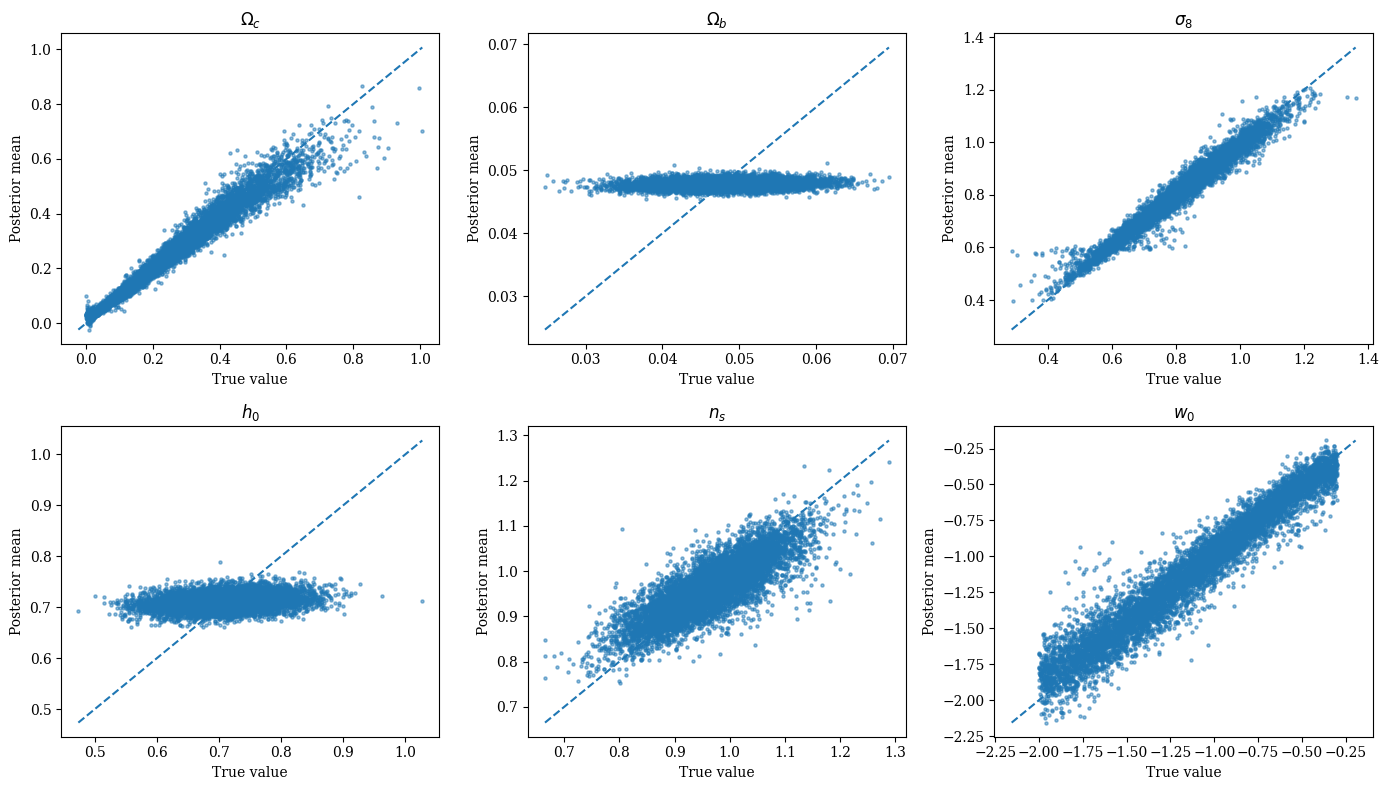

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    x = true_params[:, i].numpy()
    y = posterior_means[:, i].numpy()

    ax.scatter(x, y, s=5, alpha=0.5)
    minv = min(x.min(), y.min())
    maxv = max(x.max(), y.max())
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")

    ax.set_xlabel("True value")
    ax.set_ylabel("Posterior mean")
    ax.set_title(param_names[i])

plt.tight_layout()
plt.show()

### Credible intervals (90%)

Credible Interval Level: 90%
$\Omega_c$: Coverage = 0.978
$\Omega_b$: Coverage = 0.946
$\sigma_8$: Coverage = 0.990
$h_0$: Coverage = 0.922
$n_s$: Coverage = 0.926
$w_0$: Coverage = 0.972


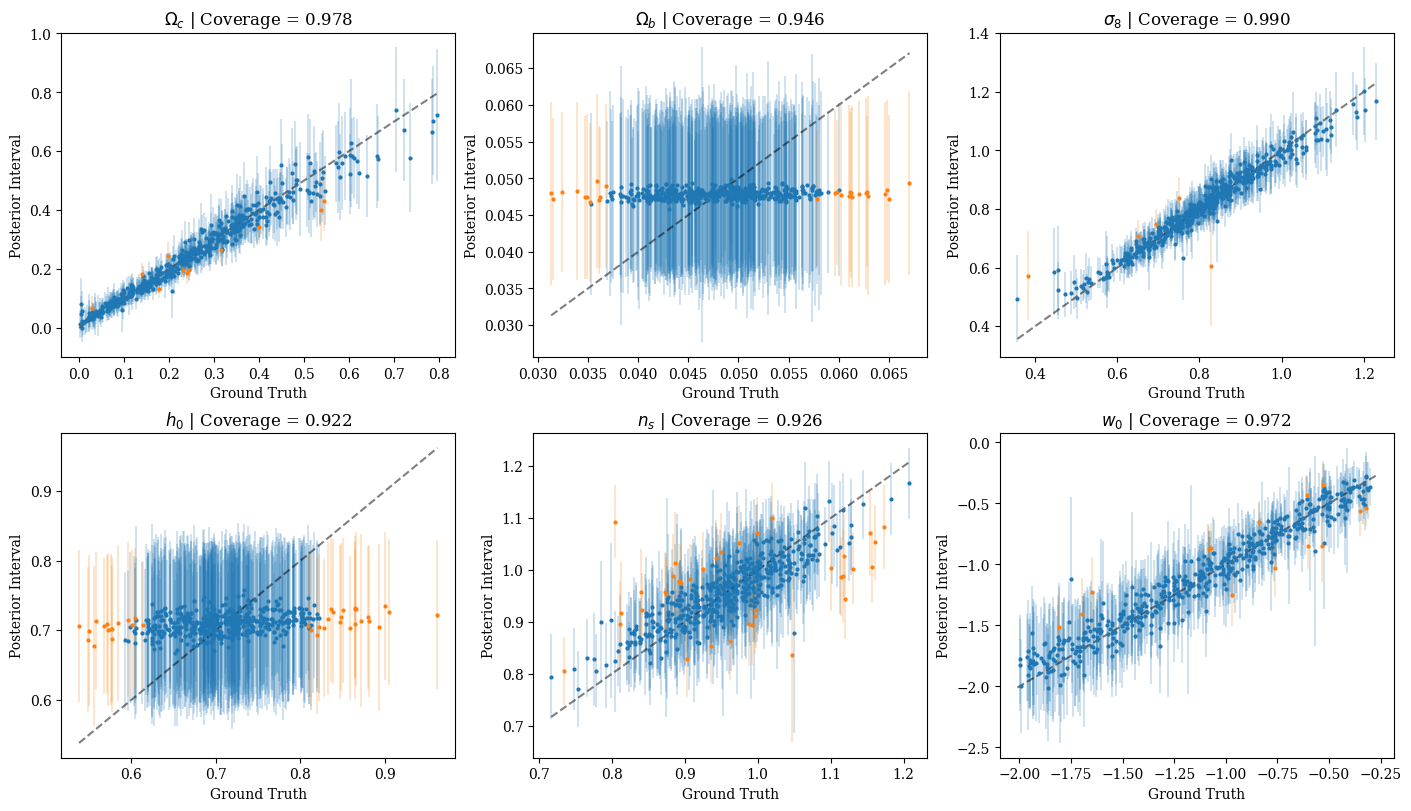

In [9]:
z_val = 1.645
n_plot = 500
rng = np.random.default_rng(42)

mu = posterior_means.numpy()
sig = posterior_stdevs.numpy()
true = true_params.numpy()

N_test = true.shape[0]
plot_idx = rng.choice(N_test, size=min(n_plot, N_test), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

print("Credible Interval Level: 90%")
for j, name in enumerate(param_names):
    x = true[plot_idx, j]
    y = mu[plot_idx, j]
    yerr = z_val * sig[plot_idx, j]
    lower = y - yerr
    upper = y + yerr
    covered = (x >= lower) & (x <= upper)
    cov = covered.mean()
    print(f"{name}: Coverage = {cov:.3f}")

    ax = axes[j]
    ax.errorbar(
        x[covered], y[covered], yerr=yerr[covered],
        fmt="o", markersize=2, alpha=1, linewidth=0.3, capsize=0,
    )
    ax.errorbar(
        x[~covered], y[~covered], yerr=yerr[~covered],
        fmt="o", markersize=2, alpha=1, linewidth=0.3, capsize=0,
    )

    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)

    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Posterior Interval")
    ax.set_title(f"{name} | Coverage = {cov:.3f}")

plt.show()

### Empirical coverage vs nominal coverage

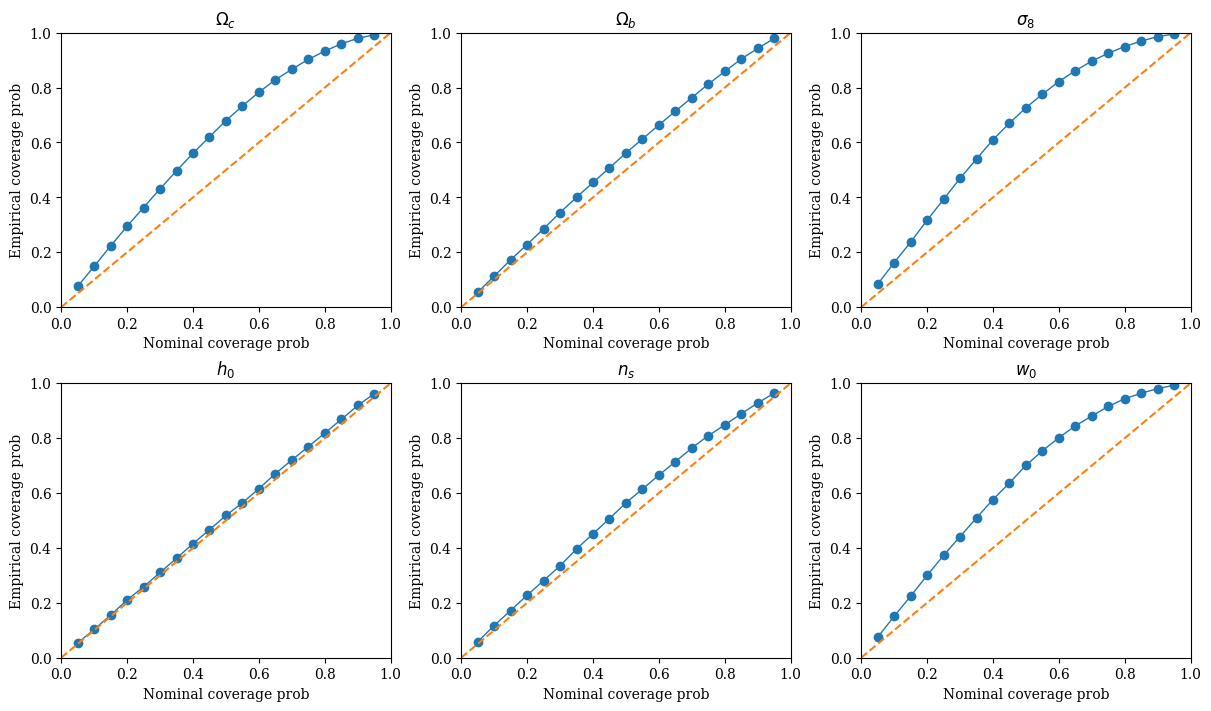

ECE per parameter:
  $\Omega_c$: 0.1248
  $\Omega_b$: 0.0460
  $\sigma_8$: 0.1521
  $h_0$: 0.0136
  $n_s$: 0.0422
  $w_0$: 0.1348


In [10]:
levels = np.linspace(0.05, 0.95, 19)
K = len(levels)

emp = np.zeros((K, 6), dtype=float)

for k, c in enumerate(levels):
    z_c = norm.ppf((1.0 + c) / 2.0)
    lo = mu - z_c * sig
    hi = mu + z_c * sig
    inside = (true >= lo) & (true <= hi)
    emp[k] = inside.mean(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
axes = axes.ravel()

for j in range(6):
    ax = axes[j]
    ax.plot(levels, emp[:, j], marker="o", linewidth=1)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(param_names[j])
    ax.set_xlabel("Nominal coverage prob")
    ax.set_ylabel("Empirical coverage prob")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.show()

ece = np.mean(np.abs(emp - levels[:, None]), axis=0)
print("ECE per parameter:")
for name, val in zip(param_names, ece):
    print(f"  {name}: {val:.4f}")